In [ ]:

# # 1-a dalis: ECG Denoising Pipeline test with a single .npy file from DATA/ZIVE_DATA
# Uses CONFIG/pipeline_config.yaml

from __future__ import annotations

from pathlib import Path
from typing import Iterable, Tuple
from typing import List, Dict, TypeAlias

import math
import numpy as np

Interval: TypeAlias = tuple[int, int]

# --- ecg_denoising_pipeline imports (as in your original) ---
from ecg_denoising_pipeline import (
    ECGDenoisingPipeline,
    DenoisingPipelineResult,
    DenoisingPipelineConfig,
    load_denoising_config_yaml,
    check_denoising_config,
    friendly_print_denoising_cfg,
    convert_seconds_to_hms,
)

from ecg_ectopy_pipeline import resolve_model_path
from record_noise_stats import calc_noise_stats_from_denoised_result


# ------------- Utilities -------------

def print_heading(title: str) -> None:
    line = '-' * max(10, len(title))
    print(f'\n{title}\n{line}')

def as_seconds(
    intervals: Iterable[Tuple[int, int]], fs: float
) -> list[Tuple[float, float]]:
    """Convert sample-based intervals to seconds."""
    return [(s / fs, e / fs) for (s, e) in intervals]

def load_array_or_fail(data_dir: Path, filename: str) -> np.ndarray:
    path = (data_dir / filename).resolve()
    if not path.exists():
        raise FileNotFoundError(f"Data file not found: {path}")
    arr = np.load(path, allow_pickle=False)
    if arr.size == 0:
        raise ValueError(f"ECG is empty: {path}")
    return arr


def list_npy_files(data_dir: Path) -> list[Path]:
    return sorted(data_dir.glob("*.npy"))


def samples_dict_to_seconds(
    d: Dict[str, List[Interval]],
    fs: float,
    ndigits: int | None = 3,  # set None to skip rounding
) -> Dict[str, List[Tuple[float, float]]]:
    out: Dict[str, List[Tuple[float, float]]] = {}
    for key, intervals in d.items():
        if not intervals:
            out[key] = []
            continue
        pairs = []
        for s, e in intervals:
            s_sec, e_sec = s / fs, e / fs
            if ndigits is not None:
                s_sec, e_sec = round(s_sec, ndigits), round(e_sec, ndigits)
            pairs.append((s_sec, e_sec))
        out[key] = pairs
    return out


# ------------- Main flow -------------

def run_denoising_pipeline(
    file_name: str | None,
    data_dir: Path,
    config_path: Path,
    model_dir: Path,
    disable_motions: bool,
) -> tuple[DenoisingPipelineResult, DenoisingPipelineConfig]:
    # Paths sanity
    if not data_dir.exists():
        raise FileNotFoundError(f"Data folder not found: {data_dir}")
    if not config_path.exists():
        raise FileNotFoundError(f"Config file not found: {config_path}")
    if not model_dir.exists():
        raise FileNotFoundError(f"Model directory not found: {model_dir}")

    # print_heading("Project paths")
    # print("DATA_DIR:", data_dir)
    # print("CONFIG  :", config_path)
    # print("MODEL_DIR:", model_dir)

    # Load config
    cfg = load_denoising_config_yaml(str(config_path))
    fs = float(cfg.fs)

    # Pick ECG file
    if file_name is None:
        files = list_npy_files(data_dir)
        if not files:
            raise FileNotFoundError(f"No .npy files in {data_dir}")
        file_path = files[0]
        file_name = file_path.name
        print(f"\nNo --file provided. Using first file found: {file_name}")
    else:
        file_path = (data_dir / file_name).resolve()

    # Load ECG
    print_heading("Input data")
    print(f"File: {file_name}")
    x = load_array_or_fail(data_dir, file_name)
    len_secs = math.ceil(len(x) / fs)
    h, m, s = convert_seconds_to_hms(len_secs)
    print(f"len(ecg): {len(x)} samples (~{len_secs:.1f} s) | {h:02d}:{m:02d}:{s:02d}")

    # start1

    # Resolve model path (robust to ~ and absolute/relative)
    cfg.motions.model_name = "resunet_ecg_1024_0_5_3_7.keras"  # adjust as needed"
    cfg.motions.model_name = resolve_model_path(model_dir, cfg.motions.model_name)

    if disable_motions:
        cfg.motions.enabled = False

    cfg.motions.threshold = 0.10 # Overide threshold for motion detection (adjust as needed)     
    
    print_heading("Denoising pipeline config")
    friendly_print_denoising_cfg(cfg)
    check_denoising_config(cfg)
    
    print_heading("UNet model")
    print("UNet model path:", cfg.motions.model_name)
    print("Motions enabled:", bool(getattr(cfg.motions, "enabled", True)))
    print("Motions threshold:", getattr(cfg.motions, "threshold", "N/A"))

    # Run pipeline
    pipe = ECGDenoisingPipeline(cfg)
    res = pipe.run(x, gaps_indices=[])

    return res, cfg


# start0
"""
Resolve key folders:
    - HERE: the project subfolder that contains CONFIG and sibling DATA/MODEL_UNET
    - ROOT: project root (parent of HERE)
    """
HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()  # UPDATE_RECORDS_LIST_ADDING_ML_NOISES
ROOT = HERE.parents[1]    # PROJECT_TRAIN_UNET
# HERE = HERE.parents[0]    # PROJECT_TRAIN_UNET
print("HERE:", HERE)
print("ROOT:", ROOT)

data_dir = ROOT / "DATA_ORIG" / "ecg_zive_npy"
cfg_dir = ROOT / "CONFIG" / "denoising_config.yaml"
model_dir = ROOT / "MODEL_UNET"  # PROJECT_TRAIN_UNET/MODEL_UNET

print("DATA_DIR:", data_dir)
print("CFG_DIR :", cfg_dir)
print("MODEL_DIR:", model_dir)

   # "Run ECG denoising pipeline on a single .npy ECG file.\n"
   # "If --file is not provided, the first .npy in DATA_DIR is used."

# Pseudo_annotated
fileNames = ['1019_118.npy'] #
fileNames = ['1001_4.npy'] #
fileNames = ['1005_2.npy'] #
fileNames = ['1008_1.npy'] #
fileNames = ['1008_10.npy'] #
fileNames = ['1019_107.npy'] #
fileNames = ['1008_8.npy'] #
fileNames = ['1008_2.npy'] # Noise stats for 1008_2.npy: out=2, rdr=0, noi=1, tp_pct=5.8
fileNames = ['1019_63.npy'] #



file_name = fileNames[0]

# Execute the pipeline in the notebook with explicit arguments
res_denoising, cfg_denoising = run_denoising_pipeline(
file_name=file_name,
data_dir=data_dir,
config_path=cfg_dir,
model_dir=model_dir,
disable_motions=False,
)

# Results
print_heading("Results for file: " + file_name)
print(f"len_original: {len(res_denoising.ecg_orig)}")
print(f"len_start   : {len(res_denoising.ecg_start)}")
print(f"len_denoised   : {len(res_denoising.ecg_denoised)}")

print("\nMaps (sample intervals):")
print("map_gaps    :", res_denoising.map_gaps)
print("map_outliers:", res_denoising.map_outliers)
print("map_rdropouts:", res_denoising.map_rdropouts)
print("map_motions :", res_denoising.map_motions)

print_heading("Detected intervals (in samples)")
print("Outliers (start):", res_denoising.outliers_indices_start)
print("Rdropouts (nout):", res_denoising.rdropouts_indices_nout)
print("Motions (nrd)   :", res_denoising.motions_indices_nrd)

print_heading("Detected intervals (in seconds)")
print("Outliers (start):", as_seconds(res_denoising.outliers_indices_start, cfg_denoising.fs))
print("Rdropouts (nout):", as_seconds(res_denoising.rdropouts_indices_nout, cfg_denoising.fs))
print("Motions (nrd)   :", as_seconds(res_denoising.motions_indices_nrd, cfg_denoising.fs))

print("\nProjected intervals (in samples):")
print("projected_to_orig", res_denoising.projected_to_orig)
print("projected_to_start", res_denoising.projected_to_start)

print("\nProjected intervals (in seconds):")
proj_orig_sec  = samples_dict_to_seconds(res_denoising.projected_to_orig,  cfg_denoising.fs,ndigits=3)
proj_start_sec = samples_dict_to_seconds(res_denoising.projected_to_start, cfg_denoising.fs,ndigits=3)

print("projected_to_orig (s):", proj_orig_sec)
print("projected_to_start (s):", proj_start_sec)
 
noise_stats = calc_noise_stats_from_denoised_result(res_denoising) or {}
unet_model_name = Path(cfg_denoising.motions.model_name).name if getattr(cfg_denoising.motions, "enabled", False) else "Motions detection disabled"
print(f"\nNoise stats for file - {file_name}  unet_model_name - {unet_model_name}  threshold - {cfg_denoising.motions.threshold}:")
print(f"out={noise_stats['out']}, rdr={noise_stats['rdr']}, noi={noise_stats['noi']}, tp_pct={noise_stats['tp_pct']:.1f}")


2026-03-09 14:51:42.391060: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773060702.451411   26161 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773060702.468317   26161 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


HERE: /home/kesju/DI/2025_ZIVEO/PROJECT_TRAIN_UNET/0_SELECT_ZIVE_DATA_2023/UPDATE_RECORDS_LIST_ADDING_ML_NOISES
ROOT: /home/kesju/DI/2025_ZIVEO/PROJECT_TRAIN_UNET
DATA_DIR: /home/kesju/DI/2025_ZIVEO/PROJECT_TRAIN_UNET/DATA_ORIG/ecg_zive_npy
CFG_DIR : /home/kesju/DI/2025_ZIVEO/PROJECT_TRAIN_UNET/CONFIG/denoising_config.yaml
MODEL_DIR: /home/kesju/DI/2025_ZIVEO/PROJECT_TRAIN_UNET/MODEL_UNET

Input data
----------
File: 1019_63.npy
len(ecg): 127999 samples (~640.0 s) | 00:10:40

Denoising pipeline config
-------------------------
🔧 Config:
{'DEBUG': False,
 'fs': 200,
 'memory_lean': True,
 'filter': {'enabled': True,
            'method': 'butterworth',
            'type': 'highpass',
            'lowcut': 0.5,
            'highcut': 70.0,
            'order': 4},
 'outliers': {'enabled': True, 'ekg_min': -3.0, 'ekg_max': 4.0, 'length_fragment': 200},
 'rdropouts': {'enabled': True, 'HR_MIN': 20, 'HR_MAX': 220, 'len_frag': 2000, 'step_size': 100},
 'motions': {'enabled': True,
          

2026-03-09 14:51:53.004688: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1773060717.309936   26250 service.cc:148] XLA service 0x7416840346e0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773060717.310363   26250 service.cc:156]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1773060718.584885   26250 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Results for file: 1019_63.npy
-----------------------------
len_original: 127999
len_start   : 127999
len_denoised   : 118592

Maps (sample intervals):
map_gaps    : IndexMap(kept=[(0, 127998, 0, 127998)])
map_outliers: IndexMap(kept=[(0, 127998, 0, 127998)])
map_rdropouts: IndexMap(kept=[(0, 127998, 0, 127998)])
map_motions : IndexMap(kept=[(1824, 11452, 0, 9628), (19036, 127998, 9629, 118591)])

Detected intervals (in samples)
-------------------------------
Outliers (start): []
Rdropouts (nout): []
Motions (nrd)   : [(0, 1823), (11453, 19035)]

Detected intervals (in seconds)
-------------------------------
Outliers (start): []
Rdropouts (nout): []
Motions (nrd)   : [(0.0, 9.115), (57.265, 95.175)]

Projected intervals (in samples):
projected_to_orig {'gaps': [], 'outliers': [], 'rdropouts': [], 'motions': [(0, 1823), (11453, 19035)]}
projected_to_start {'gaps': [], 'outliers': [], 'rdropouts': [], 'motions': [(0, 1823), (11453, 19035)]}

Projected intervals (in seconds):
projected


Showing original (after filtration) signal 1019_63.npy with ectopy annotations and noise markers
Displaying signal from 0.0 s to 639.995 s
The plot is split into fragments of 20 s
Plots will be saved to: /home/kesju/DI/2025_ZIVEO/PROJECT_TRAIN_UNET/0_SELECT_ZIVE_DATA_2023/UPDATE_RECORDS_LIST_ADDING_ML_NOISES/Plots_of_1019_63.npy_with_marked_noise_1024_0_5_3_7_0_1 (if SAVE_PLOTS is True)

unet_model_name: resunet_ecg_1024_0_5_3_7.keras
Threshold for motions (red): 0.1 (plots will be saved with suffix: _1024_0_5_3_7_0_1)

rpeaks: 634
Number of annotations: 30
Outliers intervals:0   idx(s): []
Rdropouts intervals:0   idx(s): []
Motions intervals:2   idx(s): [(0.0, 9.115), (57.265, 95.175)]


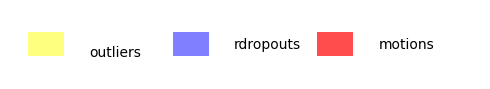

outliers-> yellow, rdropouts-> blue, motions-> red
Unmatched annot rows: 4
Finished plotting 1019_63.npy


In [4]:
# Vaizdavimas su annotacijomis 

# Vaizduojame signalą su ectopijomis : res.ecg_start
# naudojame rpeaks_on_start_df (pred_df) 
# Show denoised signal with ectopy //////////////////////////////////

from __future__ import annotations

from dataclasses import dataclass
from typing import Optional
import numpy as np
import pandas as pd

import numpy.typing as npt

from ecg_denoising_pipeline import load_nonzero_annots
from ecg_denoising_pipeline import (
    plot_ecg_annot_pred,
    divide_signal_into_fragments,
    plot_gap_legend,
)
from ecg_denoising_pipeline import map_mark_denoised_to_start, get_rpeaks
# from step_beats_no_ectopy import map_rpeaks_denoised_to_start

IntArray1D = npt.NDArray[np.int_]
BoolArray1D = npt.NDArray[np.bool_]

fs = cfg_denoising.fs

# Iš išvalyto nuo triukšmų signalo randame R-peak'us rpeaks_on_denoised
ecg_denoised = np.asarray(res_denoising.ecg_denoised).astype(float, copy=False)
rpeaks_on_denoised, _ = get_rpeaks(ecg_denoised, fs)
rpeaks_on_denoised = rpeaks_on_denoised.astype(int).tolist()

flag_show_denoised_with_ectopy = True
# Show denoised signal with annotated ectopy //////////////////////////////////

if flag_show_denoised_with_ectopy:
    
        # Prepare data for plotting

    # rpeaks_on_denoised remapiname į pradinį signalą
    rpeaks_on_start, rpeaks_on_gap = map_mark_denoised_to_start( rpeaks_on_denoised, res_denoising )
    rpeaks_on_start = np.array(rpeaks_on_start, dtype=int)

    # Jei yra ectopy annotacijos,jas užkrauname
    annot_df_: Optional[pd.DataFrame] = load_nonzero_annots(data_dir, file_name)

    # Vaizduojamas signalas su ectopijomis : res.ecg_start
    ecg_signal = res_denoising.ecg_start
    
    # R pikai ir triukšmų indeksai sekundėmis
    rpeaks_on_start_secs = np.array([x/fs for x in rpeaks_on_start])
    outliers_idx_seconds = [(s / fs, e / cfg_denoising.fs) for (s, e) in res_denoising.projected_to_start['outliers']]
    rdropouts_idx_seconds = [(s / fs, e / cfg_denoising.fs) for (s, e) in res_denoising.projected_to_start['rdropouts']]
    motions_idx_seconds = [(s / fs, e / cfg_denoising.fs) for (s, e) in res_denoising.projected_to_start['motions']]

    # gap_layers = [
    #     GapLayer(tuple(gap1_indices_secs or []), "red", 0.5),
    #     GapLayer(tuple(gap2_indices_secs or []), "blue", 0.5),
    #     GapLayer(tuple(gap3_indices_secs or []), "yellow", 0.7),
    # ]

        # Preparing plotting parameters and plotting
        
   # bendras aplankas grafikams
    unet_model_name = Path(cfg_denoising.motions.model_name).name
    MARKER = unet_model_name.removeprefix("resunet_ecg").removesuffix(".keras")  # -> "_1024_0_5_3_7"
    
    # parametrai vaizdavimui
    START_SECS = 0.0
    END_SECS = len(ecg_signal) / fs
    PORTION_LENGTH_SECS = 20
    DISPLAY_AS_SECONDS = True
    SAVE_PLOTS = True
    threshold = cfg_denoising.motions.threshold
    threshold_str = str( threshold).replace('.', '_')
    fileName = "ecg_start"
    MARKER += f"_{threshold_str}"
    # print("MARKER for plots:", MARKER)
    PLOT_DIR = HERE / (f"Plots_of_{file_name}_with_marked_noise" + MARKER)
    PLOT_SUFFIX = MARKER
    
    print(f"\nShowing original (after filtration) signal {file_name} with ectopy annotations and noise markers")
    print(f"Displaying signal from {START_SECS} s to {END_SECS} s")
    print(f"The plot is split into fragments of {PORTION_LENGTH_SECS} s")
    print(f"Plots will be saved to: {PLOT_DIR} (if SAVE_PLOTS is True)")
    print("\nunet_model_name:", unet_model_name)
    print(f"Threshold for motions (red): {threshold} (plots will be saved with suffix: {PLOT_SUFFIX})")
 
    print(f"\nrpeaks: {len(rpeaks_on_start_secs)}")
    if annot_df_ is None:
        print("No non-zero annotations found.")
    else:
        print(f"Number of annotations: {len(annot_df_)}")
    print(f"Outliers intervals:{noise_stats['out']}   idx(s): {outliers_idx_seconds}")
    print(f"Rdropouts intervals:{noise_stats['rdr']}   idx(s): {rdropouts_idx_seconds}")
    print(f"Motions intervals:{noise_stats['noi']}   idx(s): {motions_idx_seconds}")
 
    # writing notes in text file
    notes_path = PLOT_DIR / f"notes_{file_name.removesuffix('.npy')}_{PLOT_SUFFIX}.txt"
    with open(notes_path, 'w') as f:
        f.write(f"File: {file_name}\n")
        f.write(f"UNet model: {unet_model_name}\n")
        f.write(f"Threshold for motions (red): {threshold}\n")
        f.write(f"R-peaks detected: {len(rpeaks_on_start_secs)}\n")
        if annot_df_ is None:
            f.write("No non-zero annotations found.\n")
        else:
            f.write(f"Number of annotations: {len(annot_df_)}\n")
        f.write(f"Outliers intervals:{noise_stats['out']}   idx(s): {outliers_idx_seconds}\n")
        f.write(f"Rdropouts intervals:{noise_stats['rdr']}   idx(s): {rdropouts_idx_seconds}\n")
        f.write(f"Motions intervals:{noise_stats['noi']}   idx(s): {motions_idx_seconds}\n")  
 
     # Plot small rectangles and notes in one line
    plot_gap_legend('\noutliers', 'rdropouts', 'motions')
    print("outliers-> yellow, rdropouts-> blue, motions-> red")

    plot_ecg_annot_pred(
        fileName=fileName,
        ecg_signal=ecg_signal,
        fs=fs,
        plot_signal_from_in_secs=START_SECS,
        plot_signal_to_in_secs=END_SECS,
        portion_length_in_secs=PORTION_LENGTH_SECS,
        plot_save_dir=Path(PLOT_DIR) if SAVE_PLOTS else None,
        save_mark=PLOT_SUFFIX,
        recID=None,
        gap1_indices_secs=motions_idx_seconds, # red
        gap2_indices_secs=rdropouts_idx_seconds, # blue
        gap3_indices_secs=outliers_idx_seconds, # yellow
        rpeak_indices_secs=rpeaks_on_start_secs,
        annot_df=annot_df_,
        pred_df=pd.DataFrame(),
        tol_samples=10,
        flag_secs=DISPLAY_AS_SECONDS,
    )

    print("Finished plotting", file_name)